# no outlier, only correlation check, feature removal
## using log t1/2
2025-11-05, Alexander Minidis

2025-11-13 bayesian, xgboost

### Air data, only RDKIT descriptors 11/10

In [1]:
import sys
from pathlib import Path

notebookdir = Path.cwd().parents[2]
sys.path.append(str(notebookdir))  # this way we can import src modules even in different subfolders
from typing import Any
import pandas as pd
import numpy as np

import sqlalchemy as sa
from sqlalchemy.orm import sessionmaker
from src.db_utils import get_selected_data
from src.rdkit_tools import MACCS_NAMES
from src.legacy.ml_tools import decorrelate, drop_irrelevant_columns

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score, mean_absolute_error, root_mean_squared_error
import xgboost as xgb

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 250)
%matplotlib inline

In [2]:
# set directories and filenames, load database
working_dir = Path.cwd().parents[2]
data_dir = working_dir / "processed_data"
database_file = data_dir / "hsbd_t_half_all.db"
engine = sa.create_engine(f"sqlite:///{database_file}")
Session = sessionmaker(bind=engine)

In [3]:
# get all data
air_data = get_selected_data("air", Session)
soil_data = get_selected_data("soil", Session)
water_data = get_selected_data("water", Session)
sediment_data = get_selected_data("sediment", Session)


def drop_irrelevant_columns(df):
    cols_to_drop = ["id", "Canonical_smiles", "reference"]
    df = df.drop(columns=cols_to_drop, errors="ignore")
    cols_to_drop = MACCS_NAMES
    df = df.drop(columns=cols_to_drop, errors="ignore")
    return df


air_data = drop_irrelevant_columns(air_data)
water_data = drop_irrelevant_columns(water_data)
soil_data = drop_irrelevant_columns(soil_data)
sediment_data = drop_irrelevant_columns(sediment_data)

target_column = "T_half_days"

## Preprocessing

In [4]:
# we will only use air data
X, y = air_data.drop(columns=[target_column]), air_data[target_column]
print(f"Number of features: {X.shape[1]}, number of samples: {X.shape[0]}")

Number of features: 204, number of samples: 309


### scaling, decorrelation

In [5]:
# scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled = X_scaled.reset_index(drop=True)
y = y.reset_index(drop=True)

In [6]:
# remove zero std columns (no variance)
zero_std_cols = X_scaled.columns[X_scaled.std() == 0]
X_scaled = X_scaled.drop(columns=zero_std_cols)
print(f"Number of features: {X_scaled.shape[1]}, number of samples: {X_scaled.shape[0]}")

Number of features: 168, number of samples: 309


In [7]:
# drop columns hihgly correlated to some others
cols_to_drop = decorrelate(X_scaled, target_column, threshold=0.95)
X_decorrelated = X_scaled.drop(columns=cols_to_drop)
print(f"Number of features: {X_decorrelated.shape[1]}, number of samples: {X_decorrelated.shape[0]}")

Number of features: 138, number of samples: 309


In [8]:
# Ensure X_scaled and y are aligned and have no missing values
mask_notnull = X_scaled.notnull().all(axis=1) & y.notnull()
X_scaled = X_scaled[mask_notnull]
y = y[mask_notnull]
print(f"After scaling: X_scaled shape = {X_scaled.shape}, y shape = {y.shape}")

After scaling: X_scaled shape = (309, 168), y shape = (309,)


## Model

In [9]:
def output_metrics(y_true: Any, y_pred: Any) -> None:
    print(f"R2: {r2_score(y_true, y_pred):.3f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.3f}")
    print(f"MSE: {mean_squared_error(y_true, y_pred):.3f}")
    print(f"RMSE: {root_mean_squared_error(y_true, y_pred):.3f}")
    print(f"Explained Variance: {explained_variance_score(y_true, y_pred):.3f}")

In [10]:
X = X_decorrelated.copy()
y = np.log10(y)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Bayesian

In [12]:
# Bayesian Ridge Regression with GridSearchCV
param_grid = {
    "alpha_1": [1e-6, 1e-5, 1e-4, 1e-3],
    "alpha_2": [1e-6, 1e-5, 1e-4, 1e-3],
    "lambda_1": [1e-6, 1e-5, 1e-4, 1e-3],
    "lambda_2": [1e-6, 1e-5, 1e-4, 1e-3],
}

bayes_reg = BayesianRidge()
grid_search = GridSearchCV(bayes_reg, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'alpha_1': 1e-06, 'alpha_2': 0.001, 'lambda_1': 0.001, 'lambda_2': 1e-06}


R2: 0.223
MAE: 17.409
MSE: 6201.358
RMSE: 78.749
Explained Variance: 0.227


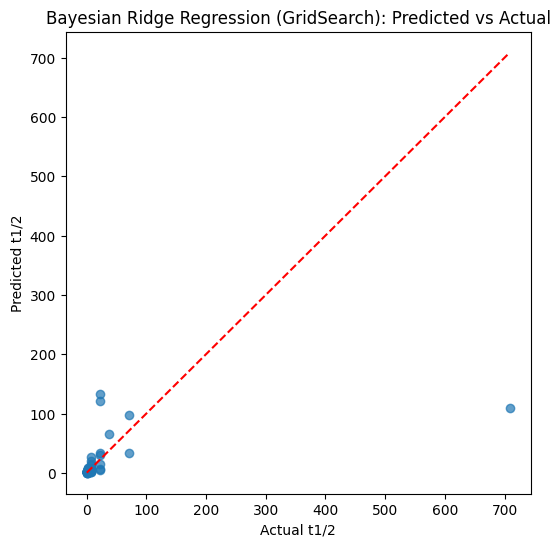

In [13]:
y_pred = grid_search.predict(X_test)

y_test_exp_bayes = np.power(10, y_test)
y_pred_exp_bayes = np.power(10, y_pred)
output_metrics(y_test_exp_bayes, y_pred_exp_bayes)

# Optional: plot predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test_exp_bayes, y_pred_exp_bayes, alpha=0.7)
plt.xlabel("Actual t1/2")
plt.ylabel("Predicted t1/2")
plt.title("Bayesian Ridge Regression (GridSearch): Predicted vs Actual")
plt.plot([y_test_exp_bayes.min(), y_test_exp_bayes.max()], [y_test_exp_bayes.min(), y_test_exp_bayes.max()], "r--")
plt.show()

Top 10 features (by absolute coefficient):
BCUT2D_MRLOW: 0.1377)
fr_aldehyde: 0.1217)
fr_Ar_N: 0.1068)
fr_allylic_oxid: 0.1028)
SlogP_VSA7: 0.1002)
fr_ketone: 0.0966)
SMR_VSA9: 0.0953)
NumSaturatedCarbocycles: 0.0944)
fr_alkyl_halide: 0.0931)
PEOE_VSA10: 0.0918)


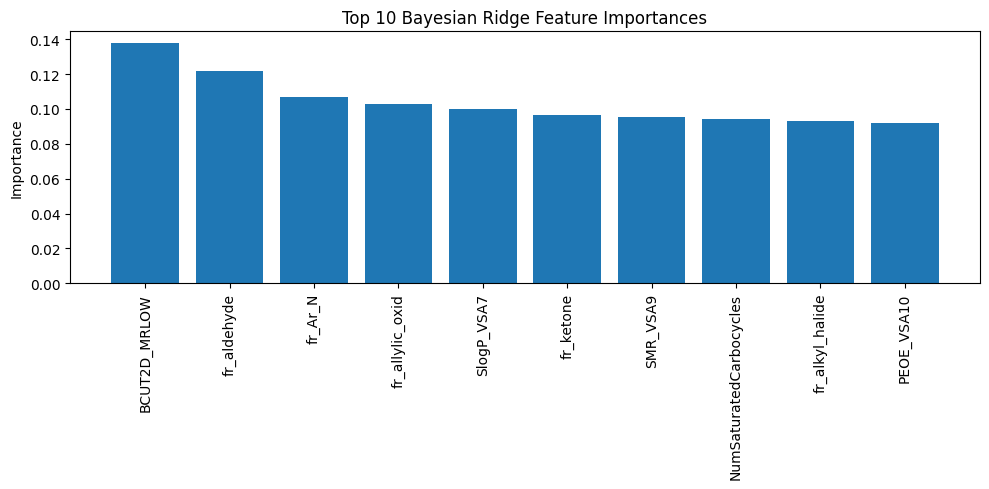

In [14]:
# Extract top 10 features by absolute coefficient value from Bayesian Ridge
importances_bayes = np.abs(grid_search.best_estimator_.coef_)
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"feat_{i}" for i in range(X_train.shape[1])]
top_idx = np.argsort(importances_bayes)[-10:][::-1]
top_features = [(feature_names[i], importances_bayes[i]) for i in top_idx]
print("Top 10 features (by absolute coefficient):")
for name, val in top_features:
    print(f"{name}: {val:.4f})")

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances_bayes[top_idx])
plt.xticks(range(10), X_train.columns[top_idx], rotation=90)
plt.title("Top 10 Bayesian Ridge Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

XGBoost

In [15]:
# XGBOOST with GridSearchCV for hyperparameter tuning

xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
param_grid = {
    "n_estimators": [100, 300, 500, 1000],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.7, 1.0],
}
# Use negative root mean squared error as scoring (available in sklearn 1.7.0)
grid_search_xgb = GridSearchCV(
    xgb_model, param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=2, error_score="raise"
)
grid_search_xgb.fit(X_train, y_train)
print("Best XGBoost parameters:", grid_search_xgb.best_params_)

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best XGBoost parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 1000, 'subsample': 0.7}


R2: 0.543
MAE: 11.424
MSE: 3650.696
RMSE: 60.421
Explained Variance: 0.547


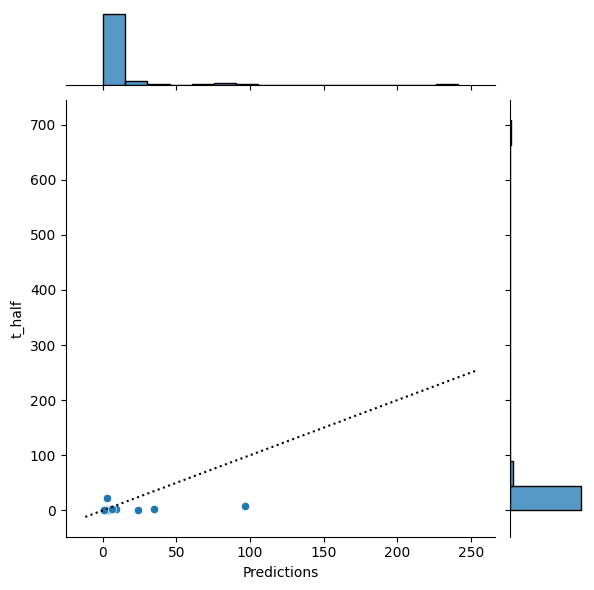

In [16]:
# Predict and evaluate XGBoost with best parameters from GridSearchCV
y_pred = grid_search_xgb.predict(X_test)
y_test_xgboost = np.power(10, y_test)
y_pred_xgboost = np.power(10, y_pred)
output_metrics(y_test_xgboost, y_pred_xgboost)
data = pd.concat([pd.Series(y_pred_xgboost), pd.Series(y_test_xgboost)], axis=1)
data.columns = ["Predictions", "t_half"]

g = sns.jointplot(x="Predictions", y="t_half", data=data)
x0, x1 = g.ax_joint.get_xlim()
y0, y1 = g.ax_joint.get_ylim()
lims = [max(x0, y0), min(x1, y1)]
g.ax_joint.plot(lims, lims, ":k")

Top 10 XGBoost features (by importance):
SMR_VSA10: 0.0986
NumHAcceptors: 0.0596
BCUT2D_MWHI: 0.0553
EState_VSA9: 0.0468
SlogP_VSA7: 0.0363
fr_alkyl_halide: 0.0261
BCUT2D_MRHI: 0.0260
SlogP_VSA5: 0.0221
SlogP_VSA2: 0.0195
fr_pyridine: 0.0189


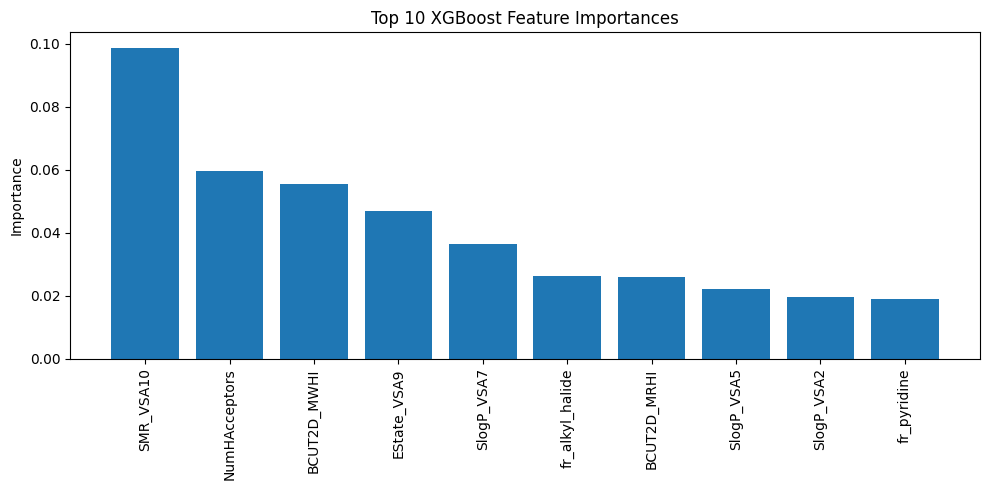

In [17]:
# Extract top 10 features by importance from XGBoost
importances_xgb = grid_search_xgb.best_estimator_.feature_importances_
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"feat_{i}" for i in range(X_train.shape[1])]
top_idx_xgb = np.argsort(importances_xgb)[-10:][::-1]
top_features_xgb = [(feature_names[i], importances_xgb[i]) for i in top_idx_xgb]
print("Top 10 XGBoost features (by importance):")
for name, val in top_features_xgb:
    print(f"{name}: {val:.4f}")

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances_xgb[top_idx_xgb])
plt.xticks(range(10), [feature_names[i] for i in top_idx_xgb], rotation=90)
plt.title("Top 10 XGBoost Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()